In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np

from cheb_ar import ChebAr
from cheb_ar.io import to_jsonable
from cheb_ar.models.ats import (
    build_ats_hamiltonian_interaction,
    transform_vectorized_state,
    KAPPA_B
)

import numpy as np

kappa_b_init = KAPPA_B
n_a, n_b = 32, 12
warm_start_file = None
cheb_degree = 8
m_arnoldi_0 = 60
m_arnoldi_first = 120
m_arnoldi_outer = 60
margin_0 = 1e-2
eps_p = .1
alpha_sq = 8

def run_for_epsp(eps_p, kappa_b, m_arnoldi, x0=None, V_prev=None):
    """Run the full pipeline for one value of ``eps_p``.

    Returns ``(result_raw, result_json)``; ``result_raw`` keeps the jax
    objects needed to warm-start the next point in-process.
    """
    (
        H_I, jump_ops_I, jump_ops_LdL_I, output_phase, V, T_block, params,
    ) = build_ats_hamiltonian_interaction(
        n_a=n_a, n_b=n_b, alpha_sq=alpha_sq,
        kappa_b=kappa_b, epsilon_p=eps_p,
    )

    solver = ChebAr(
        H_I, jump_ops_I, T_block,
        jump_ops_LdL=jump_ops_LdL_I, output_phase=output_phase,
        dims=(n_a, n_b), cheb_degree=cheb_degree,
    )

    if x0 is None:
        x0 = solver.make_x0(seed=0)
        warm_start = False
    else:
        # previous point's Ritz vector, re-expressed in this eigenbasis
        x0 = transform_vectorized_state(x0, V_prev, V)
        warm_start = True

    # First estimation + ellipse fit, with an escalation ladder on
    # failure: rerun the estimation with m_arnoldi_0 * sqrt(2), then * 2,
    # then keep that estimation and halve the margin down to 1e-5.
    min_margin = 1e-5
    m_schedule = [
        m_arnoldi_0,
        int(round(m_arnoldi_0 * np.sqrt(2))),
        2 * m_arnoldi_0,
    ]
    m_arnoldi_0_used = None
    margin_used = None
    ritz_vals = None
    last_exc = None
    margin = margin_0
    for m0 in m_schedule:
        try:
            _, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m0)
            solver.setup_chebyshev(ritz_vals, margin=margin)
            m_arnoldi_0_used, margin_used = m0, margin
            break
        except Exception as exc:
            last_exc = exc
            print(
                f"setup_chebyshev failed "
                f"(m_arnoldi_0={m0}, margin={margin:.3e}): {exc}"
            )
    if margin_used is None:
        if ritz_vals is None:
            raise last_exc  # even the first estimation itself failed
        margin = margin / 2
        while margin >= min_margin:
            try:
                solver.setup_chebyshev(ritz_vals, margin=margin)
                m_arnoldi_0_used, margin_used = m_schedule[-1], margin
                break
            except Exception as exc:
                last_exc = exc
                print(
                    f"setup_chebyshev failed "
                    f"(m_arnoldi_0={m_schedule[-1]}, margin={margin:.3e}): {exc}"
                )
                margin /= 2
        if margin_used is None:
            raise last_exc

    Q, H, mu_list = solver.arnoldi_hessenberg(
        x0, solver.chebyshev_filter, m_arnoldi, warm_start=warm_start
    )

    rate_bf = solver.rate_from_mu(mu_list[-1])
    x_ritz, _ = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
    res = solver.residual_check(x_ritz)

    result_raw = {"x_ritz": x_ritz, "V": V}
    result_json = {
        "eps_p": eps_p,
        "alpha_sq": alpha_sq,
        "kappa_b": kappa_b,
        "n_a": n_a,
        "n_b": n_b,
        "cheb_degree": cheb_degree,
        "m_arnoldi_0": m_arnoldi_0_used,
        "margin": margin_used,
        "m_arnoldi": m_arnoldi,
        "rate_bf": to_jsonable(rate_bf),
        "x_ritz": to_jsonable(x_ritz),
        "res": to_jsonable(res),
        "params": to_jsonable(params),
    }
    return result_raw, result_json

In [ ]:
eps_p_list = np.linspace(0.1, 1.1, 6)
eps_p_init = eps_p_list[0]

results = []
prev = None  # raw result of the last successful point
for eps_p in eps_p_list:
    # keep the adiabatic ratio kappa_b / g constant across the sweep
    kappa_b = np.sin(eps_p) / np.sin(eps_p_init) * kappa_b_init

    warm = prev is not None
    m_arnoldi = m_arnoldi_outer if warm else m_arnoldi_first
    try:
        if warm:
            result_raw, result = run_for_epsp(
                eps_p, kappa_b, m_arnoldi,
                x0=prev["x_ritz"], V_prev=prev["V"],
            )
        else:
            result_raw, result = run_for_epsp(eps_p, kappa_b, m_arnoldi)
    except Exception as exc:
        print(f"eps_p = {eps_p} FAILED: {exc}")
        results.append({
            "eps_p": float(eps_p),
            "alpha_sq": alpha_sq,
            "kappa_b": float(kappa_b),
            "n_a": n_a,
            "n_b": n_b,
            "cheb_degree": cheb_degree,
            "m_arnoldi_0": m_arnoldi_0,
            "m_arnoldi": m_arnoldi,
            "error": f"{type(exc).__name__}: {exc}",
        })
        prev = None
        continue

    print(f"eps_p = {eps_p}")
    print(f"rate_bf  = {result['rate_bf']}")
    print(f"res_rel  = {result['res']['res_rel']}")
    results.append(result)
    prev = result_raw

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:534: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  result = self.data + y.data
|██████████| 100.0% ◆ elapsed 232.87ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 197.86ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 198.76ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 198.00ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆

setup_chebyshev failed (m_arnoldi_0=60, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 204.25ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.63ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.34ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.95ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 202.69ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 201.07ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 195.76ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 194.80ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 194.41ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 189.33ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 186.62ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 188.62ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 184.53ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 188.40ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 182.99ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 184.75ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 187.11ms ◆ remaining 0.00m

setup_chebyshev failed (m_arnoldi_0=85, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 203.20ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.01ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 199.77ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 199.35ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 201.82ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 200.52ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 195.48ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 193.55ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 195.52ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 187.13ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 185.53ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 187.82ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 183.78ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 187.14ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 180.57ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 182.85ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 185.31ms ◆ remaining 0.00m

...

setup_chebyshev failed (m_arnoldi_0=85, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 244.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 210.53ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 204.60ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 210.33ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 211.04ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 205.44ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 208.11ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 205.06ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 197.56ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 189.69ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 193.13ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 193.05ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 191.32ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 191.33ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 189.55ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 192.40ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 191.87ms ◆ remaining 0.00

setup_chebyshev failed (m_arnoldi_0=120, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.
setup_chebyshev failed (m_arnoldi_0=120, margin=5.000e-03): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.005; try a smaller margin or a different num_a.
setup_chebyshev failed (m_arnoldi_0=120, margin=2.500e-03): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.0025; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 254.82ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 247.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 328.79ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 446.06ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 560.72ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 673.66ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 757.03ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 835.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 201.79ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 253.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 366.61ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 495.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 662.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 838.45ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 1.01s ◆ remaining 0.00ms     
|██████████| 100.0% ◆ elapsed 1.14s ◆ remaining 0.00ms     
|██████████| 100.0% ◆ elapsed 192.93ms ◆ 

eps_p = 1.5 FAILED: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
  File "/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
  File "/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/home/tmalasda/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/home/tmalasda/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
  File "/home/tmalasda/.local/share/uv/python

In [8]:
bf_list_dict = [{'real': 7.010670615079977e-07, 'imag': 2.195205466617801e-16}, 
           {'real': 2.4418745000890262e-05, 'imag': 3.099188624302594e-16}, 
           {'real': 0.00015413077651167467, 'imag': -1.6364578340657382e-16},
            {'real': 0.0005388382545509475, 'imag': 1.1886130801020534e-16},
            {'real': 0.0013518707369447741, 'imag': 7.054814422613457e-17},
            {'real': 0.0034259646991887916, 'imag': -4.012764268341791e-17}]
bf_list = np.array([bf["real"]+1j*bf["imag"] for bf in bf_list_dict])

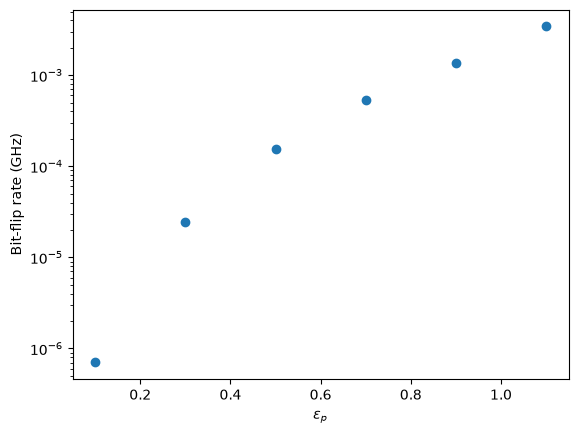

In [9]:
import matplotlib.pyplot as plt
plt.scatter(eps_p_list, bf_list.real)
plt.yscale("log")
plt.ylabel("Bit-flip rate (GHz)")
plt.xlabel(r"$\varepsilon_p$")
plt.show()

In [12]:
from cheb_ar.models.ats import E_J, PHI_A, PHI_B
from scipy.special import jv
g_2 = jv(1,eps_p_list) * E_J * PHI_A**2 * PHI_B /2/np.pi*1e3

In [17]:
kappa_b_list = np.array([r["kappa_b"] for r in results])

In [18]:
kappa_b_list/g_2

array([0.10541256, 0.10505928, 0.10434407, 0.103249  , 0.10174532,
       0.09979099])